<a href="https://colab.research.google.com/github/ibrahimhanifceker/YZ50Codes/blob/main/hafta-4/YZ50Hafta4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [842]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [843]:
import os

if not os.path.exists("names.txt"):
    !wget https://raw.githubusercontent.com/karpathy/makemore/refs/heads/master/names.txt

print("names.txt is downloaded")

names.txt is downloaded


In [844]:
words = open("names.txt", 'r').read().splitlines()

chars = sorted(list(set(''.join(words))))
chars = ['.'] + chars
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}

In [845]:
num_vocab = len(chars)
context_size = 3
emb_dim = 2
hidden_dim = 100
batch_size = 32

In [846]:
X, Y = [], []

for word in words:
    context = [0] * context_size
    for ch in word + '.':
        idx = stoi[ch]
        X.append(context)
        Y.append(idx)
        context = context[1:] + [idx]

X = torch.tensor(X)
Y = torch.tensor(Y)

In [847]:
g = torch.Generator().manual_seed(42)

C = torch.randn((num_vocab, emb_dim),                           generator=g)
weight1 = torch.randn((context_size * emb_dim, hidden_dim),     generator=g)
bias1 = torch.randn((hidden_dim,),                              generator=g)
weight2 = torch.randn((hidden_dim, num_vocab),                  generator=g)
bias2 = torch.randn((num_vocab,),                               generator=g)
parameters = [C, weight1, bias1, weight2, bias2]

In [848]:
emb = C[X]
emb.shape
hidden_layer = torch.tanh(emb.reshape(len(X), -1) @ weight1 + bias1)
logits = hidden_layer @ weight2 + bias2

counts = logits.exp()
probs = counts / counts.sum(dim=1, keepdim=True)
manual_loss = -probs[torch.arange(len(X)), Y].log().mean()

cross_entropy_loss = F.cross_entropy(logits, Y)

print(f"Elle hesaplanan loss: {manual_loss.item()} | Cross entropy ile hesaplanan loss: {cross_entropy_loss}")

Elle hesaplanan loss: 16.72646713256836 | Cross entropy ile hesaplanan loss: 16.726470947265625


In [849]:
for param in parameters:
    param.requires_grad = True

In [850]:
temp_X = X[:32]
temp_Y = Y[:32]

epochs = 100
learning_rate = 0.1

for epoch in range(epochs):
    emb = C[temp_X]
    hidden_layer = torch.tanh(emb.reshape(len(temp_X), -1) @ weight1 + bias1)
    logits = hidden_layer @ weight2 + bias2
    loss = F.cross_entropy(logits, temp_Y)
    if epoch % 10 == 0:
        print(f"Epochs: {epoch} | Loss: {loss}")

    for param in parameters:
        param.grad = None

    loss.backward()

    for param in parameters:
        param.data += -learning_rate * param.grad

print(loss.item())

Epochs: 0 | Loss: 17.775842666625977
Epochs: 10 | Loss: 4.3454132080078125
Epochs: 20 | Loss: 1.2727065086364746
Epochs: 30 | Loss: 0.4890214204788208
Epochs: 40 | Loss: 0.3547118902206421
Epochs: 50 | Loss: 0.32074666023254395
Epochs: 60 | Loss: 0.30477234721183777
Epochs: 70 | Loss: 0.2951887845993042
Epochs: 80 | Loss: 0.28871577978134155
Epochs: 90 | Loss: 0.284017413854599
0.28075531125068665


In [851]:
g = torch.Generator().manual_seed(42)

C = torch.randn((num_vocab, emb_dim),                           generator=g)
weight1 = torch.randn((context_size * emb_dim, hidden_dim),     generator=g)
bias1 = torch.randn((hidden_dim,),                              generator=g)
weight2 = torch.randn((hidden_dim, num_vocab),                  generator=g)
bias2 = torch.randn((num_vocab,),                               generator=g)
parameters = [C, weight1, bias1, weight2, bias2]

for param in parameters:
    param.requires_grad = True

In [852]:
epochs = 5000
learning_rate = 0.1

for epoch in range(epochs):
    idx = torch.randint(0, len(X), (batch_size,))
    emb = C[X[idx]]
    hidden_layer = torch.tanh(emb.reshape(batch_size, -1) @ weight1 + bias1)
    logits = hidden_layer @ weight2 + bias2
    loss = F.cross_entropy(logits, Y[idx])

    for param in parameters:
        param.grad = None

    loss.backward()

    for param in parameters:
        param.data += -learning_rate * param.grad

print(loss.item())

2.5953166484832764


In [853]:
g = torch.Generator().manual_seed(42)

C = torch.randn((num_vocab, emb_dim),                           generator=g)
weight1 = torch.randn((context_size * emb_dim, hidden_dim),     generator=g)
bias1 = torch.randn((hidden_dim,),                              generator=g)
weight2 = torch.randn((hidden_dim, num_vocab),                  generator=g)
bias2 = torch.randn((num_vocab,),                               generator=g)
parameters = [C, weight1, bias1, weight2, bias2]

for param in parameters:
    param.requires_grad = True

In [854]:
lr_exp = torch.linspace(-3, 0, 2000)
lr_vals = 10**lr_exp

In [855]:
epochs = 2000
# learning_rate = 0.1

lrs_used = []
loss_vals = []

for epoch in range(epochs):
    idx = torch.randint(0, len(X), (batch_size,))
    emb = C[X[idx]]
    hidden_layer = torch.tanh(emb.reshape(batch_size, -1) @ weight1 + bias1)
    logits = hidden_layer @ weight2 + bias2
    loss = F.cross_entropy(logits, Y[idx])

    for param in parameters:
        param.grad = None

    loss.backward()

    learning_rate = lr_vals[epoch]
    lrs_used.append(lr_exp[epoch])
    loss_vals.append(loss.item())

    for param in parameters:
        param.data += -learning_rate * param.grad

print(loss.item())

4.408424377441406


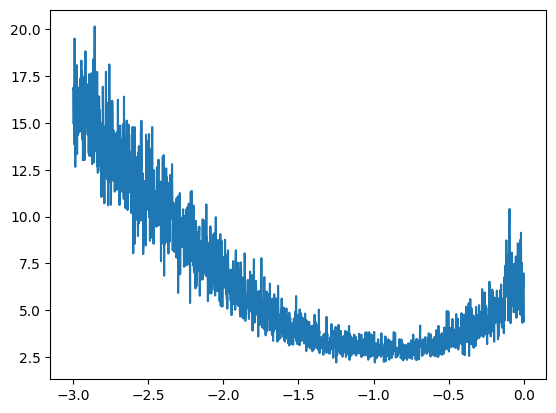

In [856]:
plt.plot(lrs_used, loss_vals);

In [857]:
g = torch.Generator().manual_seed(42)

C = torch.randn((num_vocab, emb_dim),                           generator=g)
weight1 = torch.randn((context_size * emb_dim, hidden_dim),     generator=g)
bias1 = torch.randn((hidden_dim,),                              generator=g)
weight2 = torch.randn((hidden_dim, num_vocab),                  generator=g)
bias2 = torch.randn((num_vocab,),                               generator=g)
parameters = [C, weight1, bias1, weight2, bias2]

for param in parameters:
    param.requires_grad = True

In [858]:
epochs = 30000
learning_rate = 0.1

for epoch in range(epochs):
    idx = torch.randint(0, len(X), (batch_size,))
    emb = C[X[idx]]
    hidden_layer = torch.tanh(emb.reshape(batch_size, -1) @ weight1 + bias1)
    logits = hidden_layer @ weight2 + bias2
    loss = F.cross_entropy(logits, Y[idx])

    for param in parameters:
        param.grad = None

    loss.backward()

    if epoch > 20000:
        learning_rate = 0.01

    for param in parameters:
        param.data += -learning_rate * param.grad

print(loss.item())

2.310234308242798


In [859]:
def get_entire_data_loss():
    idx = torch.randint(0, len(X), (batch_size,))
    emb = C[X]
    hidden_layer = torch.tanh(emb.reshape(len(X), -1) @ weight1 + bias1)
    logits = hidden_layer @ weight2 + bias2
    loss = F.cross_entropy(logits, Y)
    return loss.item()

print(get_entire_data_loss())

2.337515115737915


In [860]:
import random

def build_dataset(words):
    x, y = [], []
    for word in words:
        context = [0] * context_size
        for ch in word + '.':
            idx = stoi[ch]
            x.append(context)
            y.append(idx)
            context = context[1:] + [idx]
    x = torch.tensor(x)
    y = torch.tensor(y)
    return x, y

random.seed(42)
words_copy = words.copy()
random.shuffle(words_copy)
tr_split = int(0.8 * len(words_copy))
dev_split = int(0.9 * len(words_copy))

Xtr, Ytr = build_dataset(words_copy[:tr_split])
Xdev, Ydev = build_dataset(words_copy[tr_split:dev_split])
Xte, Yte = build_dataset(words_copy[dev_split:])

@torch.inference_mode()
def get_loss(split):
    x, y = {
        "train": {Xtr, Ytr},
        "dev": {Xdev, Ydev},
        "test": {Xte, Yte},
    }[split]
    emb = C[x]
    hidden_layer = torch.tanh(emb.reshape(len(x), -1) @ weight1 + bias1)
    logits = hidden_layer @ weight2 + bias2
    loss = F.cross_entropy(logits, y)
    return loss.item()

In [861]:
g = torch.Generator().manual_seed(42)

C = torch.randn((num_vocab, emb_dim),                           generator=g)
weight1 = torch.randn((context_size * emb_dim, hidden_dim),     generator=g)
bias1 = torch.randn((hidden_dim,),                              generator=g)
weight2 = torch.randn((hidden_dim, num_vocab),                  generator=g)
bias2 = torch.randn((num_vocab,),                               generator=g)
parameters = [C, weight1, bias1, weight2, bias2]

for param in parameters:
    param.requires_grad = True

In [862]:
epochs = 30000
learning_rate = 0.1

for epoch in range(epochs):
    idx = torch.randint(0, len(Xtr), (batch_size,))
    emb = C[Xtr[idx]]
    hidden_layer = torch.tanh(emb.reshape(batch_size, -1) @ weight1 + bias1)
    logits = hidden_layer @ weight2 + bias2
    loss = F.cross_entropy(logits, Ytr[idx])

    for param in parameters:
        param.grad = None

    loss.backward()

    if epoch > 20000:
        learning_rate = 0.01

    for param in parameters:
        param.data += -learning_rate * param.grad

print(loss.item())

2.3183162212371826


In [863]:
print(get_loss("dev"))

2.343040704727173


In [864]:
print(get_loss("test"))

2.3397974967956543


In [865]:
hidden_dim = 300

In [866]:
g = torch.Generator().manual_seed(42)

C = torch.randn((num_vocab, emb_dim),                           generator=g)
weight1 = torch.randn((context_size * emb_dim, hidden_dim),     generator=g)
bias1 = torch.randn((hidden_dim,),                              generator=g)
weight2 = torch.randn((hidden_dim, num_vocab),                  generator=g)
bias2 = torch.randn((num_vocab,),                               generator=g)
parameters = [C, weight1, bias1, weight2, bias2]

for param in parameters:
    param.requires_grad = True

In [867]:
epochs = 30000
learning_rate = 0.1
epoch_vals = []
loss_vals = []

for epoch in range(epochs):
    idx = torch.randint(0, len(Xtr), (batch_size,))
    emb = C[Xtr[idx]]
    hidden_layer = torch.tanh(emb.reshape(batch_size, -1) @ weight1 + bias1)
    logits = hidden_layer @ weight2 + bias2
    loss = F.cross_entropy(logits, Ytr[idx])

    for param in parameters:
        param.grad = None

    loss.backward()

    epoch_vals.append(epoch)
    loss_vals.append(loss.item())

    if epoch > 20000:
        learning_rate = 0.01

    for param in parameters:
        param.data += -learning_rate * param.grad

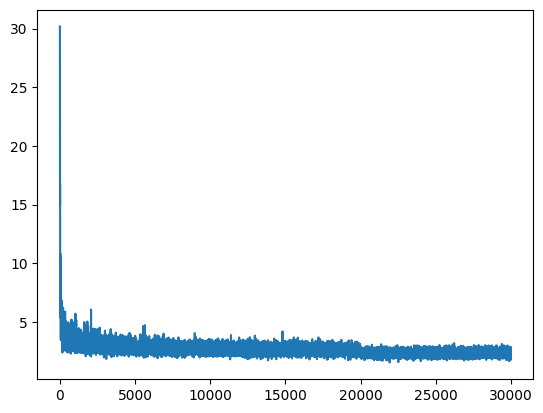

In [868]:
plt.plot(epoch_vals, loss_vals);

In [869]:
print(get_loss("train"))

2.3279037475585938


In [870]:
print(get_loss("dev"))

2.32547664642334


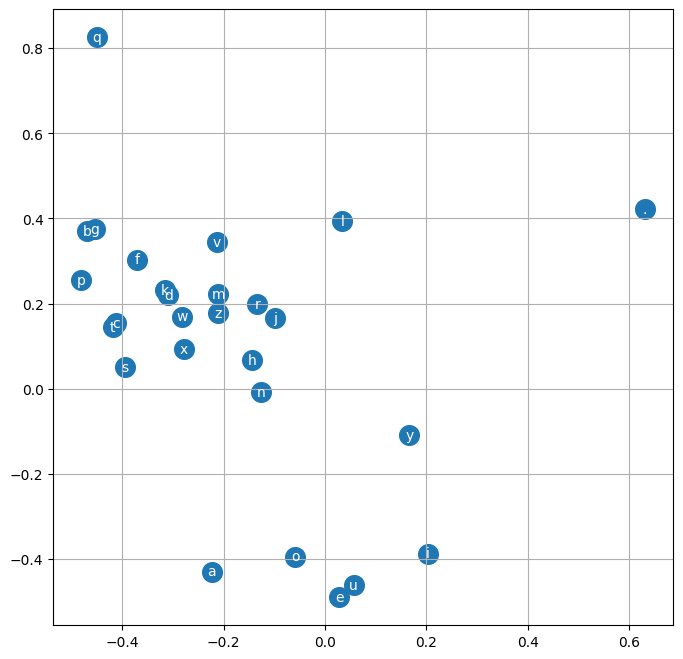

In [871]:
plt.figure(figsize=(8, 8))
plt.scatter(C[:, 0].data, C[:, 1].data, s=200)
for i in range(len(C)):
    plt.text(C[i,0].item(), C[i, 1].item(), itos[i], ha="center", va="center", color="white")
plt.grid('minor');

In [872]:
hidden_dim = 200
emb_dim = 10

In [873]:
g = torch.Generator().manual_seed(42)

C = torch.randn((num_vocab, emb_dim),                           generator=g)
weight1 = torch.randn((context_size * emb_dim, hidden_dim),     generator=g)
bias1 = torch.randn((hidden_dim,),                              generator=g)
weight2 = torch.randn((hidden_dim, num_vocab),                  generator=g)
bias2 = torch.randn((num_vocab,),                               generator=g)
parameters = [C, weight1, bias1, weight2, bias2]

for param in parameters:
    param.requires_grad = True

In [874]:
epochs = 100000
learning_rate = 0.1
epoch_vals = []
loss_vals = []

for epoch in range(epochs):
    idx = torch.randint(0, len(Xtr), (batch_size,))
    emb = C[Xtr[idx]]
    hidden_layer = torch.tanh(emb.reshape(batch_size, -1) @ weight1 + bias1)
    logits = hidden_layer @ weight2 + bias2
    loss = F.cross_entropy(logits, Ytr[idx])

    for param in parameters:
        param.grad = None

    loss.backward()

    epoch_vals.append(epoch)
    loss_vals.append(loss.log10().item())

    if epoch > 50000:
        learning_rate = 0.01

    for param in parameters:
        param.data += -learning_rate * param.grad

In [875]:
get_loss("train"), get_loss("dev"), get_loss("test")

(2.1728315353393555, 2.207583427429199, 2.197727918624878)

In [876]:
num_names = 20

g = torch.Generator().manual_seed(42)

for _ in range(num_names):
    name = []
    context = [0] * context_size
    while True:
        emb = C[torch.tensor(context)]
        hidden_layer = torch.tanh(emb.reshape(1, -1) @ weight1 + bias1)
        logits = hidden_layer @ weight2 + bias2
        probs = F.softmax(logits, dim=1)
        idx = torch.multinomial(probs, num_samples=1, generator=g).item()

        if idx == 0:
            break
        name.append(itos[idx])
        context = context[1:] + [idx]
    print(''.join(name))

anu
den
tis
marian
dan
shan
silaylen
keman
linan
eliah
nesilanzi
kence
jordon
kalla
mikolynn
khvihiana
salin
tian
tiyan
mar


In [897]:
def training_loop():
    epochs = 200000
    learning_rate = 0.1

    for epoch in range(epochs):
        idx = torch.randint(0, len(Xtr), (batch_size,))
        emb = C[Xtr[idx]]
        hidden_layer = torch.tanh(emb.reshape(batch_size, -1) @ weight1 + bias1)
        logits = hidden_layer @ weight2 + bias2
        loss = F.cross_entropy(logits, Ytr[idx])

        for param in parameters:
            param.grad = None

        loss.backward()

        if epoch >= 100000:
            learning_rate = 0.01

        for param in parameters:
            param.data += -learning_rate * param.grad

        if epoch % 10000 == 0:
            print(f"{epoch:7d}/{epochs:7d}: Loss = {loss.item():.4f}")

    print(f"Train loss:{get_loss("train")} | Dev loss: {get_loss("dev")} | Test loss: {get_loss("test")}")
    return

In [898]:
def first_iteration():
    idx = torch.randint(0, len(Xtr), (batch_size,))
emb = C[Xtr[idx]]
hidden_layer = torch.tanh(emb.reshape(batch_size, -1) @ weight1 + bias1)
logits = hidden_layer @ weight2 + bias2
loss = F.cross_entropy(logits, Ytr[idx])

print(f"First iteration loss: {loss.item()}")

First iteration loss: 2.091952323913574


In [899]:
g = torch.Generator().manual_seed(42)

C = torch.randn((num_vocab, emb_dim),                           generator=g)
weight1 = torch.randn((context_size * emb_dim, hidden_dim),     generator=g)
bias1 = torch.randn((hidden_dim,),                              generator=g)
weight2 = torch.randn((hidden_dim, num_vocab),                  generator=g)
bias2 = torch.randn((num_vocab,),                               generator=g)
parameters = [C, weight1, bias1, weight2, bias2]

for param in parameters:
    param.requires_grad = True

In [900]:
training_loop()

      0/ 200000: Loss = 26.1730
  10000/ 200000: Loss = 2.0820
  20000/ 200000: Loss = 2.4232
  30000/ 200000: Loss = 2.1910
  40000/ 200000: Loss = 2.5827
  50000/ 200000: Loss = 2.3874
  60000/ 200000: Loss = 2.6969
  70000/ 200000: Loss = 2.2819
  80000/ 200000: Loss = 2.6106
  90000/ 200000: Loss = 2.3507
 100000/ 200000: Loss = 2.5064
 110000/ 200000: Loss = 1.9676
 120000/ 200000: Loss = 1.8589
 130000/ 200000: Loss = 2.1069
 140000/ 200000: Loss = 2.0352
 150000/ 200000: Loss = 2.1140
 160000/ 200000: Loss = 2.1326
 170000/ 200000: Loss = 1.6435
 180000/ 200000: Loss = 2.1777
 190000/ 200000: Loss = 2.0061
Train loss:2.1250171661376953 | Dev loss: 2.1778860092163086 | Test loss: 2.1745901107788086


In [901]:
logits = torch.zeros(10)
probs = torch.softmax(logits, dim=0)
loss = -probs[5].log()
print(logits, f"Loss: {loss.item()}")

logits = torch.randn(10)
probs = torch.softmax(logits, dim=0)
loss = -probs[5].log()
print(logits, f"Loss: {loss.item()}")

logits = torch.randn(10) * 20
probs = torch.softmax(logits, dim=0)
loss = -probs[5].log()
print(logits, f"Loss: {loss.item()}")

logits = torch.randn(10) * 100
probs = torch.softmax(logits, dim=0)
loss = -probs[5].log()
print(logits, f"Loss: {loss.item()}")

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]) Loss: 2.3025851249694824
tensor([-1.1889, -2.2872, -0.1293,  0.0899,  0.9704,  0.0280, -0.3639, -0.6376,
         1.2384,  2.1847]) Loss: 2.9479482173919678
tensor([  0.7356,  17.6265, -33.4484,   1.5475, -12.5367,   2.1978,  -7.8639,
         -2.0382, -22.3265,  -7.1851]) Loss: 15.428701400756836
tensor([ -58.9008,   37.4401,  -44.7599, -144.2144, -113.9327,   84.9217,
          -7.6413,  -75.2732,  -55.5914,   50.3380]) Loss: -0.0


In [902]:
g = torch.Generator().manual_seed(42)

C = torch.randn((num_vocab, emb_dim),                           generator=g)
weight1 = torch.randn((context_size * emb_dim, hidden_dim),     generator=g)
bias1 = torch.randn((hidden_dim,),                              generator=g)
weight2 = torch.randn((hidden_dim, num_vocab),                  generator=g) * 0.1
bias2 = torch.randn((num_vocab,),                               generator=g) * 0
parameters = [C, weight1, bias1, weight2, bias2]

for param in parameters:
    param.requires_grad = True

In [903]:
first_iteration()

In [904]:
training_loop()

      0/ 200000: Loss = 3.6264
  10000/ 200000: Loss = 1.9728
  20000/ 200000: Loss = 2.3610
  30000/ 200000: Loss = 2.0455
  40000/ 200000: Loss = 2.0257
  50000/ 200000: Loss = 2.0295
  60000/ 200000: Loss = 2.2150
  70000/ 200000: Loss = 2.0348
  80000/ 200000: Loss = 2.0247
  90000/ 200000: Loss = 2.6945
 100000/ 200000: Loss = 2.2755
 110000/ 200000: Loss = 1.8526
 120000/ 200000: Loss = 1.9410
 130000/ 200000: Loss = 2.4122
 140000/ 200000: Loss = 2.0514
 150000/ 200000: Loss = 1.5733
 160000/ 200000: Loss = 2.2002
 170000/ 200000: Loss = 2.1509
 180000/ 200000: Loss = 2.1767
 190000/ 200000: Loss = 2.2091
Train loss:2.06868052482605 | Dev loss: 2.1329922676086426 | Test loss: 2.13053297996521


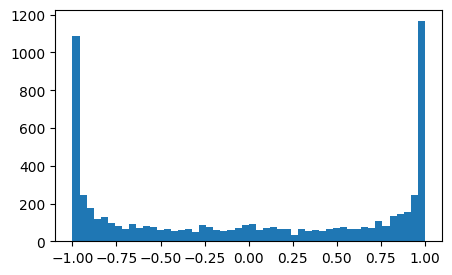

In [905]:
plt.figure(figsize=(5,3))
plt.hist(hidden_layer.reshape(-1).tolist(), 50);

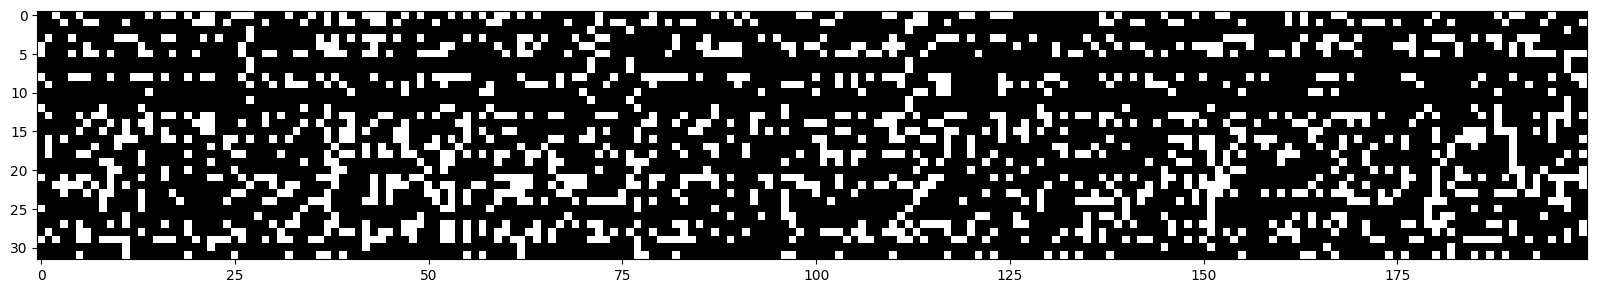

In [906]:
plt.figure(figsize=(20,10))
plt.imshow(hidden_layer.abs() > 0.99, cmap='gray', interpolation='nearest');

In [907]:
g = torch.Generator().manual_seed(42)

C = torch.randn((num_vocab, emb_dim),                           generator=g)
weight1 = torch.randn((context_size * emb_dim, hidden_dim),     generator=g) * 0.2
bias1 = torch.randn((hidden_dim,),                              generator=g) * 0.01
weight2 = torch.randn((hidden_dim, num_vocab),                  generator=g) * 0.1
bias2 = torch.randn((num_vocab,),                               generator=g) * 0
parameters = [C, weight1, bias1, weight2, bias2]

for param in parameters:
    param.requires_grad = True

In [908]:
first_iteration()

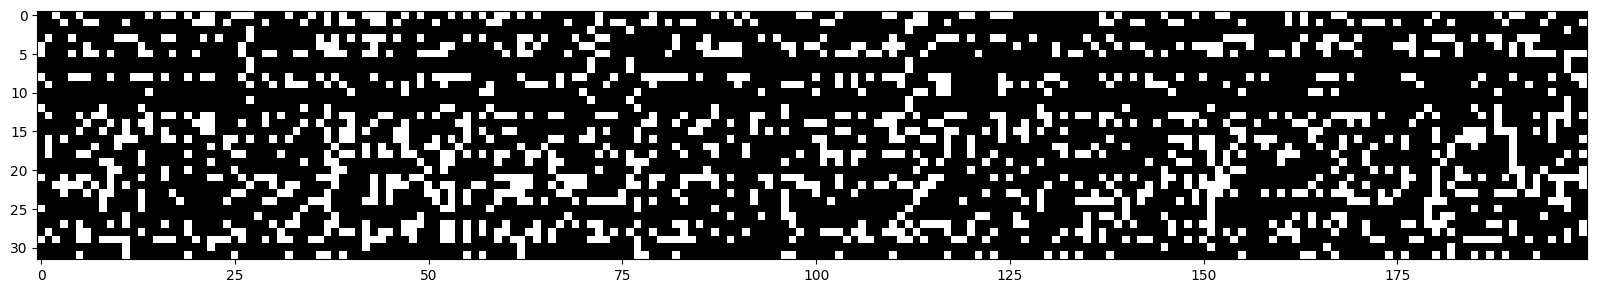

In [909]:
plt.figure(figsize=(20,10))
plt.imshow(hidden_layer.abs() > 0.99, cmap='gray', interpolation='nearest');

In [910]:
training_loop()

      0/ 200000: Loss = 3.8798
  10000/ 200000: Loss = 2.4723
  20000/ 200000: Loss = 2.3110
  30000/ 200000: Loss = 1.8583
  40000/ 200000: Loss = 2.3979
  50000/ 200000: Loss = 2.3185
  60000/ 200000: Loss = 2.5438
  70000/ 200000: Loss = 2.0750
  80000/ 200000: Loss = 2.3592
  90000/ 200000: Loss = 2.0697
 100000/ 200000: Loss = 2.0558
 110000/ 200000: Loss = 2.3221
 120000/ 200000: Loss = 2.2449
 130000/ 200000: Loss = 2.0708
 140000/ 200000: Loss = 2.0104
 150000/ 200000: Loss = 2.0138
 160000/ 200000: Loss = 2.0445
 170000/ 200000: Loss = 1.9227
 180000/ 200000: Loss = 2.2993
 190000/ 200000: Loss = 2.1184
Train loss:2.036804676055908 | Dev loss: 2.1023218631744385 | Test loss: 2.107844829559326


In [911]:
g = torch.Generator().manual_seed(42)

C = torch.randn((num_vocab, emb_dim),                           generator=g)
weight1 = torch.randn((context_size * emb_dim, hidden_dim),     generator=g) * (5/3) / (context_size * emb_dim)**0.5
bias1 = torch.randn((hidden_dim,),                              generator=g) * 0.01
weight2 = torch.randn((hidden_dim, num_vocab),                  generator=g) * 0.1
bias2 = torch.randn((num_vocab,),                               generator=g) * 0
parameters = [C, weight1, bias1, weight2, bias2]

for param in parameters:
    param.requires_grad = True

In [912]:
training_loop()

      0/ 200000: Loss = 3.5736
  10000/ 200000: Loss = 2.4160
  20000/ 200000: Loss = 1.8877
  30000/ 200000: Loss = 2.4616
  40000/ 200000: Loss = 2.0488
  50000/ 200000: Loss = 2.5941
  60000/ 200000: Loss = 1.8935
  70000/ 200000: Loss = 2.3744
  80000/ 200000: Loss = 1.7957
  90000/ 200000: Loss = 1.9494
 100000/ 200000: Loss = 2.1097
 110000/ 200000: Loss = 2.1023
 120000/ 200000: Loss = 2.2683
 130000/ 200000: Loss = 1.8934
 140000/ 200000: Loss = 1.8976
 150000/ 200000: Loss = 1.7838
 160000/ 200000: Loss = 1.9404
 170000/ 200000: Loss = 2.2419
 180000/ 200000: Loss = 2.0788
 190000/ 200000: Loss = 1.7495
Train loss:2.040609359741211 | Dev loss: 2.1096158027648926 | Test loss: 2.104346990585327
